<a href="https://colab.research.google.com/github/pedro-muqoyat/Eksperimen_SML_lifani/blob/main/Eksperimen_lifani.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [ ]:
# Pustaka untuk manipulasi struktur data (DataFrame) dan komputasi numerik
import pandas as pd
import numpy as np

# Pustaka untuk visualisasi grafis
import matplotlib.pyplot as plt
import seaborn as sns

# Pustaka utama Machine Learning (Scikit-Learn)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [ ]:
# Mounting Google Drive (Akan memunculkan pop-up izin akses akun Google)
from google.colab import drive
drive.mount('/content/drive')

# Mendefinisikan lokasi file dataset (path absolut)
file_path = "/content/drive/MyDrive/DICODING/Proyek_Submission_Akhir/dataset.csv"

# Membaca file CSV ke dalam format Pandas DataFrame
df = pd.read_csv(file_path)

# Menampilkan 5 baris pertama untuk verifikasi integritas pemuatan data
display(df.head())

Mounted at /content/drive


,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,8,5,2,1,1,1,13,10,6,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,6,1,11,1,1,1,1,3,4,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,5,1,1,1,22,27,10,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,8,2,15,1,1,1,23,27,6,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,12,1,3,0,1,1,22,28,10,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

--- INFORMASI STRUKTUR DATA ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 35 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance                      4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Nacionality                                     4424 non-null   int64  
 7   Mother's qualification                          4424 non-null   int64  
 8   Father's qualification                          4424 non-null   int64  
 9   Mother's 

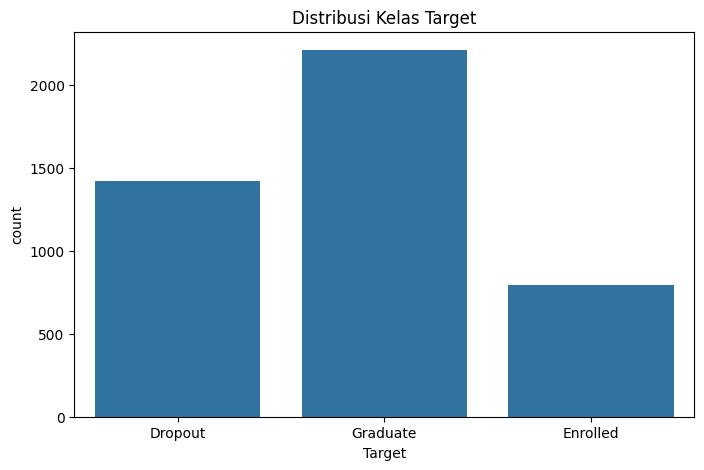

In [ ]:
# 1. Inspeksi tipe data tiap kolom dan pengecekan jumlah total baris
print("--- INFORMASI STRUKTUR DATA ---")
df.info()

# 2. Pengecekan jumlah nilai yang kosong (Missing Values)
print("\n--- JUMLAH DATA KOSONG TIAP KOLOM ---")
print(df.isnull().sum())

# 3. Visualisasi sederhana: Menghitung jumlah kategori pada kolom target (misal: 'Target')
plt.figure(figsize=(8, 5))
sns.countplot(x='Target', data=df)
plt.title('Distribusi Kelas Target')
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [ ]:
# 1. Menghapus baris yang memiliki nilai kosong dan duplikasi
df_clean = df.dropna().drop_duplicates()

# 2. Memisahkan kolom fitur (X) dan kolom target (y)
X = df_clean.drop(columns=['Target'])
y = df_clean['Target']

# 3. Mengubah teks pada kolom target menjadi angka (Encoding)
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

# 4. Membagi data menjadi data latih (80%) dan data uji (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42
)

# 5. Menyamakan skala angka pada data latih dan data uji (Standarisasi)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Proses Preprocessing Selesai. Data siap dilatih.")
print(f"Dimensi Data Latih: {X_train_scaled.shape}")
print(f"Dimensi Data Uji: {X_test_scaled.shape}")

Proses Preprocessing Selesai. Data siap dilatih.
Dimensi Data Latih: (3539, 34)
Dimensi Data Uji: (885, 34)


In [ ]:
# ==============================================================================
# TAHAP 0: ALOKASI DEPENDENSI RUNTIME (RESOLUSI GALAT)
# ==============================================================================
# Perintah ini akan mengunduh dan memasang modul yang hilang ke dalam mesin virtual
!pip install mlflow dagshub scikit-learn pandas numpy matplotlib seaborn

# ==============================================================================
# TAHAP 1: KONFIGURASI KONEKSI REMOTE TRACKING (DAGSHUB & MLFLOW)
# ==============================================================================
import mlflow
import mlflow.sklearn
import dagshub
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

# Injeksi kredensial operasional deterministik
DAGSHUB_USERNAME = "pedro-muqoyat"
DAGSHUB_REPO = "lifani"

# Inisialisasi token keamanan dan endpoint pelacakan cloud
dagshub.init(repo_owner=DAGSHUB_USERNAME, repo_name=DAGSHUB_REPO, mlflow=True)
mlflow.set_tracking_uri(f"https://dagshub.com/{DAGSHUB_USERNAME}/{DAGSHUB_REPO}.mlflow")
mlflow.set_experiment("Eksperimen_Prediksi_Status_Akademik")

# ==============================================================================
# TAHAP 2: PENINGKATAN PERFORMA MODEL (HYPERPARAMETER TUNING)
# ==============================================================================
# Menggunakan algoritma Random Forest Classifier sebagai dasar estimator
base_model = RandomForestClassifier(random_state=42)

# Menentukan matriks parameter komputasional
param_space = {
    'n_estimators': [50, 100],
    'max_depth': [10, None],
    'class_weight': ['balanced']
}

# Setup pencarian parameter terbaik menggunakan metode 3-Fold Cross Validation
grid_search = GridSearchCV(estimator=base_model, param_grid=param_space, cv=3, scoring='accuracy', n_jobs=-1)

# ==============================================================================
# TAHAP 3: ISOLASI PROSES DAN MANUAL LOGGING METRIK KE CLOUD SERVER
# ==============================================================================
# Membuka ruang eksekusi pelacakan MLflow secara formal
with mlflow.start_run(run_name="Eksperimen_RandomForest_V1"):

    print("Memulai proses komputasi tuning parameter model...")
    # Instruksi pelatihan model terhadap matriks fitur X_train_scaled
    grid_search.fit(X_train_scaled, y_train)

    # Mengekstraksi arsitektur model terbaik hasil optimisasi
    best_pipeline_model = grid_search.best_estimator_

    # Melakukan inferensi/prediksi terhadap data uji (X_test_scaled)
    predictions = best_pipeline_model.predict(X_test_scaled)

    # Menghitung metrik performa kuantitatif secara deterministik
    final_accuracy = accuracy_score(y_test, predictions)
    final_f1_weighted = f1_score(y_test, predictions, average='weighted')

    # --- PROSES LOGGING EKSPLISIT ---
    mlflow.log_params(grid_search.best_params_)
    mlflow.log_metric("akurasi_pengujian", final_accuracy)
    mlflow.log_metric("f1_score_bobot", final_f1_weighted)
    mlflow.sklearn.log_model(best_pipeline_model, "model_klasifikasi_mahasiswa")

    # --- PEMBUATAN ARTEFAK VISUAL (CONFUSION MATRIX) ---
    import matplotlib.pyplot as plt
    import seaborn as sns

    cm = confusion_matrix(y_test, predictions)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
                xticklabels=encoder.classes_, yticklabels=encoder.classes_)
    plt.title('Matriks Evaluasi Prediksi Model')
    plt.ylabel('Status Aktual')
    plt.xlabel('Hasil Prediksi')

    # Penyimpanan metrik spasial dan pengiriman ke server DagsHub
    graph_filename = "evaluasi_confusion_matrix.png"
    plt.savefig(graph_filename, bbox_inches='tight')
    mlflow.log_artifact(graph_filename)
    plt.close()

    # ==============================================================================
    # TAHAP 4: MENAMPILKAN RINGKASAN EVALUASI PADA TERMINAL
    # ==============================================================================
    print("\n================ EKSEKUSI PIPELINE SELESAI ================")
    print(f"Kombinasi Parameter Optimal: {grid_search.best_params_}")
    print(f"Metrik Akurasi Akhir       : {final_accuracy:.4f}")
    print(f"Metrik F1-Score (Weighted) : {final_f1_weighted:.4f}")
    print("\n--- LAPORAN KLASIFIKASI DETAIL ---")
    print(classification_report(y_test, predictions, target_names=encoder.classes_))

❗❗❗ AUTHORIZATION REQUIRED ❗❗❗

Output()



Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=fd723c79-2250-477b-b40d-94329d1cca30&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=67861363d2c8d21130fd857746bef96448c5f6701c9a968d89859adc89ff75c2




Accessing as pedro-muqoyat

Initialized MLflow to track repo "pedro-muqoyat/lifani"

Repository pedro-muqoyat/lifani initialized!

2026/07/02 18:06:20 INFO mlflow.tracking.fluent: Experiment with name 'Eksperimen_Prediksi_Status_Akademik' does not exist. Creating a new experiment.


Memulai proses komputasi tuning parameter model...


2026/07/02 18:06:28 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



================ EKSEKUSI PIPELINE SELESAI ================
Kombinasi Parameter Optimal: {'class_weight': 'balanced', 'max_depth': None, 'n_estimators': 100}
Metrik Akurasi Akhir       : 0.7593
Metrik F1-Score (Weighted) : 0.7417

--- LAPORAN KLASIFIKASI DETAIL ---
              precision    recall  f1-score   support

     Dropout       0.83      0.76      0.79       316
    Enrolled       0.56      0.30      0.39       151
    Graduate       0.75      0.93      0.83       418

    accuracy                           0.76       885
   macro avg       0.71      0.66      0.67       885
weighted avg       0.75      0.76      0.74       885

🏃 View run Eksperimen_RandomForest_V1 at: https://dagshub.com/pedro-muqoyat/lifani.mlflow/#/experiments/0/runs/e0ac9b24f79d49b5a3cfbe423c967313
🧪 View experiment at: https://dagshub.com/pedro-muqoyat/lifani.mlflow/#/experiments/0
